Kasus 1


===== PROSES EVOLUSI =====

Gen   0 | Fitness: 85 | Avg: 46.58
Gen   5 | Fitness: 100 | Avg: 88.50
Gen  10 | Fitness: 100 | Avg: 91.00
Gen  15 | Fitness: 100 | Avg: 91.75
Gen  20 | Fitness: 100 | Avg: 88.00

🎯 SOLUSI OPTIMAL DITEMUKAN!

===== HASIL AKHIR =====
Fitness akhir : 100

Jadwal Final:
 - ('AI', 'D1', 'R1', 'P4')
 - ('DB', 'D1', 'R1', 'P3')
 - ('WEB', 'D2', 'R2', 'P2')
 - ('ML', 'D2', 'R2', 'P1')
 - ('IOT', 'D3', 'R1', 'P2')
 - ('SE', 'D3', 'R2', 'P4')
 - ('DS', 'D1', 'R1', 'P1')

Penjelasan:
Tidak ada konflik → solusi optimal.


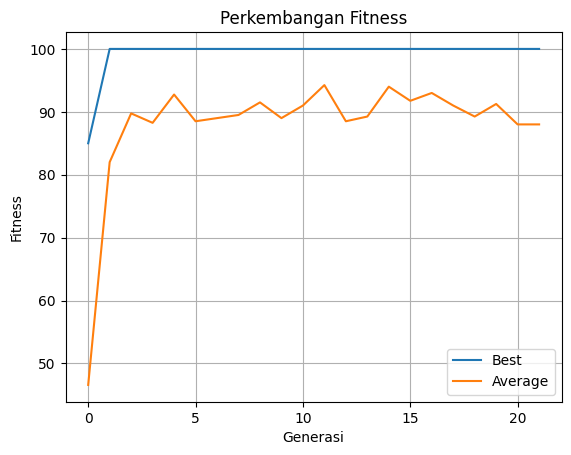

In [ ]:
import random 
import matplotlib.pyplot as plt

# =========================================================
# DATA (SUDAH FIX)
# =========================================================
courses = ["AI", "DB", "WEB", "ML", "IOT", "SE", "DS"]

rooms = ["R1", "R2"]
times = ["P1", "P2", "P3", "P4"]  # 🔥 FIX: tambah slot

lecturers = {
    "AI": "D1",
    "DB": "D1",
    "WEB": "D2",
    "ML": "D2",
    "IOT": "D3",
    "SE": "D3",
    "DS": "D1"
}

POP_SIZE = 60
GENERATIONS = 200
MUTATION_RATE = 0.3
ELITE_SIZE = 3

# =========================================================
# INIT
# =========================================================
def create_schedule():
    return [(c, lecturers[c], random.choice(rooms), random.choice(times)) for c in courses]

def init_population():
    return [create_schedule() for _ in range(POP_SIZE)]

# =========================================================
# KONFLIK
# =========================================================
def conflict_details(schedule):
    room_time = {}
    lecturer_time = {}
    details = []

    for course, lec, room, time in schedule:

        if (room, time) in room_time:
            details.append(f"{course} bentrok RUANG dengan {room_time[(room,time)]} di {room}-{time}")
        else:
            room_time[(room, time)] = course

        if (lec, time) in lecturer_time:
            details.append(f"{course} bentrok DOSEN dengan {lecturer_time[(lec,time)]} di {time}")
        else:
            lecturer_time[(lec, time)] = course

    return details

# =========================================================
# FITNESS
# =========================================================
def fitness(schedule):
    conflicts = conflict_details(schedule)
    score = 100 - len(conflicts) * 15
    return max(score, 0)

# =========================================================
# REPAIR (SMART)
# =========================================================
def repair(schedule):
    used = set()

    for i in range(len(schedule)):
        c, lec, room, time = schedule[i]

        if (room, time) in used:
            for r in rooms:
                for t in times:
                    if (r, t) not in used:
                        schedule[i] = (c, lec, r, t)
                        used.add((r, t))
                        break
                else:
                    continue
                break
        else:
            used.add((room, time))

    return schedule

# =========================================================
# SELECTION
# =========================================================
def selection(pop):
    return max(random.sample(pop, 3), key=fitness)

# =========================================================
# CROSSOVER
# =========================================================
def crossover(p1, p2):
    point = random.randint(1, len(p1)-1)
    return p1[:point] + p2[point:]

# =========================================================
# MUTATION
# =========================================================
def mutate(schedule):
    i = random.randint(0, len(schedule)-1)
    c, lec, _, _ = schedule[i]
    schedule[i] = (c, lec, random.choice(rooms), random.choice(times))
    return schedule

# =========================================================
# GA
# =========================================================
def GA():
    pop = init_population()

    best_hist = []
    avg_hist = []

    print("\n===== PROSES EVOLUSI =====\n")

    for gen in range(GENERATIONS):

        pop = sorted(pop, key=fitness, reverse=True)

        best = pop[0]
        best_fit = fitness(best)
        avg_fit = sum(fitness(p) for p in pop) / POP_SIZE

        best_hist.append(best_fit)
        avg_hist.append(avg_fit)

        if gen % 5 == 0:
            print(f"Gen {gen:3d} | Fitness: {best_fit} | Avg: {avg_fit:.2f}")

        # 🔥 jangan terlalu cepat stop
        if best_fit == 100 and gen > 20:
            print("\n🎯 SOLUSI OPTIMAL DITEMUKAN!")
            break

        new_pop = pop[:ELITE_SIZE]

        while len(new_pop) < POP_SIZE:
            p1 = selection(pop)
            p2 = selection(pop)

            child = crossover(p1, p2)

            if random.random() < MUTATION_RATE:
                child = mutate(child)

            # tidak selalu repair → biar evolusi terlihat
            if random.random() < 0.7:
                child = repair(child)

            new_pop.append(child)

        pop = new_pop

    # =====================================================
    # HASIL AKHIR
    # =====================================================
    best = sorted(pop, key=fitness, reverse=True)[0]
    conflicts = conflict_details(best)

    print("\n===== HASIL AKHIR =====")
    print("Fitness akhir :", fitness(best))

    print("\nJadwal Final:")
    for s in best:
        print(" -", s)

    if not conflicts:
        print("\nPenjelasan:")
        print("Tidak ada konflik → solusi optimal.")
    else:
        print("\nPenjelasan:")
        print(f"Terdapat {len(conflicts)} konflik:")
        for c in conflicts:
            print(" -", c)

    # =====================================================
    # VISUAL
    # =====================================================
    plt.figure()
    plt.plot(best_hist)
    plt.plot(avg_hist)
    plt.title("Perkembangan Fitness")
    plt.xlabel("Generasi")
    plt.ylabel("Fitness")
    plt.legend(["Best", "Average"])
    plt.grid()
    plt.show()


# RUN
if __name__ == "__main__":
    GA()

Kasus 2


===== PROSES EVOLUSI (KNAPSACK) =====

Gen   0 | Best Value: 520 | Avg: 219.80
Gen   5 | Best Value: 530 | Avg: 278.80
Gen  10 | Best Value: 530 | Avg: 277.60
Gen  15 | Best Value: 530 | Avg: 281.60
Gen  20 | Best Value: 530 | Avg: 274.60
Gen  25 | Best Value: 530 | Avg: 306.60
Gen  30 | Best Value: 530 | Avg: 254.80
Gen  35 | Best Value: 530 | Avg: 293.80
Gen  40 | Best Value: 530 | Avg: 283.60
Gen  45 | Best Value: 530 | Avg: 323.00
Gen  50 | Best Value: 530 | Avg: 279.60
Gen  55 | Best Value: 530 | Avg: 266.40
Gen  60 | Best Value: 530 | Avg: 319.00
Gen  65 | Best Value: 530 | Avg: 325.20
Gen  70 | Best Value: 530 | Avg: 264.40
Gen  75 | Best Value: 530 | Avg: 263.40
Gen  80 | Best Value: 530 | Avg: 274.40
Gen  85 | Best Value: 530 | Avg: 254.60
Gen  90 | Best Value: 530 | Avg: 331.20
Gen  95 | Best Value: 530 | Avg: 288.40

===== HASIL AKHIR =====
Barang terpilih : ['Laptop', 'HP', 'Jaket', 'Kamera']
Total berat     : 7
Total nilai     : 530
Penjelasan: Solusi valid dan optimal.


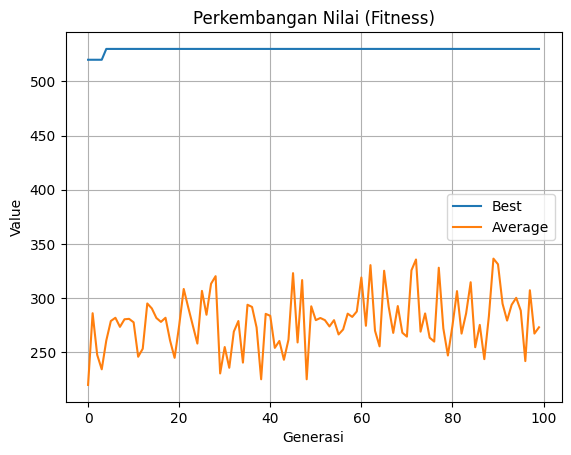

In [ ]:
import random
import matplotlib.pyplot as plt

# =========================================================
# DATA BARANG
# =========================================================
items = [
    ("Laptop", 3, 200),
    ("HP", 1, 100),
    ("Buku", 2, 60),
    ("Jaket", 2, 80),
    ("Kamera", 1, 150),
    ("Sepatu", 2, 70),
    ("Powerbank", 1, 40),
]

MAX_WEIGHT = 7

POP_SIZE = 50
GENERATIONS = 100
MUTATION_RATE = 0.2
ELITE_SIZE = 2

# =========================================================
# INIT
# =========================================================
def create_individual():
    return [random.randint(0,1) for _ in items]

def init_population():
    return [create_individual() for _ in range(POP_SIZE)]

# =========================================================
# FITNESS
# =========================================================
def fitness(individual):
    total_weight = 0
    total_value = 0

    for gene, (name, w, v) in zip(individual, items):
        if gene == 1:
            total_weight += w
            total_value += v

    # penalti jika overweight
    if total_weight > MAX_WEIGHT:
        return 0

    return total_value

# =========================================================
# SELECTION
# =========================================================
def selection(pop):
    return max(random.sample(pop, 3), key=fitness)

# =========================================================
# CROSSOVER
# =========================================================
def crossover(p1, p2):
    point = random.randint(1, len(p1)-1)
    return p1[:point] + p2[point:]

# =========================================================
# MUTATION
# =========================================================
def mutate(ind):
    for i in range(len(ind)):
        if random.random() < MUTATION_RATE:
            ind[i] = 1 - ind[i]
    return ind

# =========================================================
# ANALISIS
# =========================================================
def decode(ind):
    selected = []
    total_weight = 0
    total_value = 0

    for gene, (name, w, v) in zip(ind, items):
        if gene == 1:
            selected.append(name)
            total_weight += w
            total_value += v

    return selected, total_weight, total_value

# =========================================================
# GA
# =========================================================
def GA():
    pop = init_population()

    best_hist = []
    avg_hist = []

    print("\n===== PROSES EVOLUSI (KNAPSACK) =====\n")

    for gen in range(GENERATIONS):

        pop = sorted(pop, key=fitness, reverse=True)

        best = pop[0]
        best_fit = fitness(best)
        avg_fit = sum(fitness(p) for p in pop) / POP_SIZE

        best_hist.append(best_fit)
        avg_hist.append(avg_fit)

        if gen % 5 == 0:
            print(f"Gen {gen:3d} | Best Value: {best_fit} | Avg: {avg_fit:.2f}")

        new_pop = pop[:ELITE_SIZE]

        while len(new_pop) < POP_SIZE:
            p1 = selection(pop)
            p2 = selection(pop)

            child = crossover(p1, p2)
            child = mutate(child)

            new_pop.append(child)

        pop = new_pop

    # =====================================================
    # HASIL
    # =====================================================
    best = sorted(pop, key=fitness, reverse=True)[0]
    selected, weight, value = decode(best)

    print("\n===== HASIL AKHIR =====")
    print("Barang terpilih :", selected)
    print("Total berat     :", weight)
    print("Total nilai     :", value)

    if weight <= MAX_WEIGHT:
        print("Penjelasan: Solusi valid dan optimal.")
    else:
        print("Penjelasan: Melebihi kapasitas (tidak valid).")

    # =====================================================
    # VISUAL
    # =====================================================
    plt.figure()
    plt.plot(best_hist)
    plt.plot(avg_hist)
    plt.title("Perkembangan Nilai (Fitness)")
    plt.xlabel("Generasi")
    plt.ylabel("Value")
    plt.legend(["Best", "Average"])
    plt.grid()
    plt.show()


# RUN
GA()

Kasus 3


===== OPTIMASI JADWAL BELAJAR =====

Gen   0 | Fitness: 100
Gen   5 | Fitness: 100

🎯 Jadwal optimal ditemukan!

===== HASIL AKHIR =====
Fitness : 100
AI → Sore
DB → Pagi
WEB → Dini
ML → Siang
IOT → Malam

Penjelasan:
Tidak ada bentrok → jadwal optimal.


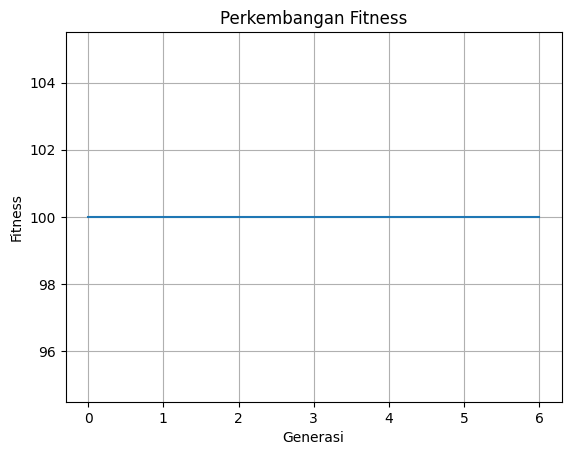

In [ ]:
import random
import matplotlib.pyplot as plt

# =========================================================
# DATA (SUDAH FIX)
# =========================================================
subjects = ["AI", "DB", "WEB", "ML", "IOT"]

# 🔥 ditambah agar cukup
times = ["Pagi", "Siang", "Sore", "Malam", "Dini"]

POP_SIZE = 30
GENERATIONS = 100
MUTATION_RATE = 0.2

# =========================================================
# INIT
# =========================================================
def create_schedule():
    return [random.choice(times) for _ in subjects]

def init_population():
    return [create_schedule() for _ in range(POP_SIZE)]

# =========================================================
# HITUNG KONFLIK
# =========================================================
def count_conflicts(schedule):
    used = set()
    conflicts = 0

    for t in schedule:
        if t in used:
            conflicts += 1
        else:
            used.add(t)

    return conflicts

# =========================================================
# FITNESS
# =========================================================
def fitness(schedule):
    conflicts = count_conflicts(schedule)
    return max(100 - conflicts * 20, 0)

# =========================================================
# SELECTION
# =========================================================
def selection(pop):
    return max(random.sample(pop, 3), key=fitness)

# =========================================================
# CROSSOVER
# =========================================================
def crossover(p1, p2):
    point = random.randint(1, len(p1)-1)
    return p1[:point] + p2[point:]

# =========================================================
# MUTATION
# =========================================================
def mutate(schedule):
    for i in range(len(schedule)):
        if random.random() < MUTATION_RATE:
            schedule[i] = random.choice(times)
    return schedule

# =========================================================
# DECODE
# =========================================================
def decode(schedule):
    return list(zip(subjects, schedule))

# =========================================================
# GA
# =========================================================
def GA():
    pop = init_population()
    best_hist = []

    print("\n===== OPTIMASI JADWAL BELAJAR =====\n")

    for gen in range(GENERATIONS):

        pop = sorted(pop, key=fitness, reverse=True)

        best = pop[0]
        best_fit = fitness(best)

        best_hist.append(best_fit)

        if gen % 5 == 0:
            print(f"Gen {gen:3d} | Fitness: {best_fit}")

        if best_fit == 100 and gen > 5:
            print("\n🎯 Jadwal optimal ditemukan!")
            break

        new_pop = pop[:2]

        while len(new_pop) < POP_SIZE:
            p1 = selection(pop)
            p2 = selection(pop)

            child = crossover(p1, p2)
            child = mutate(child)

            new_pop.append(child)

        pop = new_pop

    # =====================================================
    # HASIL AKHIR
    # =====================================================
    best = sorted(pop, key=fitness, reverse=True)[0]
    conflicts = count_conflicts(best)

    print("\n===== HASIL AKHIR =====")
    print("Fitness :", fitness(best))

    for subj, t in decode(best):
        print(f"{subj} → {t}")

    print("\nPenjelasan:")
    if conflicts == 0:
        print("Tidak ada bentrok → jadwal optimal.")
    else:
        print(f"Terdapat {conflicts} bentrok waktu.")
        if len(subjects) > len(times):
            print("Penyebab: slot waktu tidak cukup.")

    # =====================================================
    # VISUAL
    # =====================================================
    plt.figure()
    plt.plot(best_hist)
    plt.title("Perkembangan Fitness")
    plt.xlabel("Generasi")
    plt.ylabel("Fitness")
    plt.grid()
    plt.show()

# RUN
GA()

Kasus 4


===== OPTIMASI UANG JAJAN =====

Gen   0 | Nilai kepuasan: 240
Gen   5 | Nilai kepuasan: 250
Gen  10 | Nilai kepuasan: 250
Gen  15 | Nilai kepuasan: 250
Gen  20 | Nilai kepuasan: 250
Gen  25 | Nilai kepuasan: 250
Gen  30 | Nilai kepuasan: 250
Gen  35 | Nilai kepuasan: 250
Gen  40 | Nilai kepuasan: 250
Gen  45 | Nilai kepuasan: 250
Gen  50 | Nilai kepuasan: 250
Gen  55 | Nilai kepuasan: 250
Gen  60 | Nilai kepuasan: 250
Gen  65 | Nilai kepuasan: 250
Gen  70 | Nilai kepuasan: 250
Gen  75 | Nilai kepuasan: 250
Gen  80 | Nilai kepuasan: 250
Gen  85 | Nilai kepuasan: 250
Gen  90 | Nilai kepuasan: 250
Gen  95 | Nilai kepuasan: 250

===== HASIL AKHIR =====
Pilihan: ['Makan', 'Kopi', 'Transport', 'Internet']
Total biaya: 50000
Total kepuasan: 250
Penjelasan: Pengeluaran optimal sesuai budget.


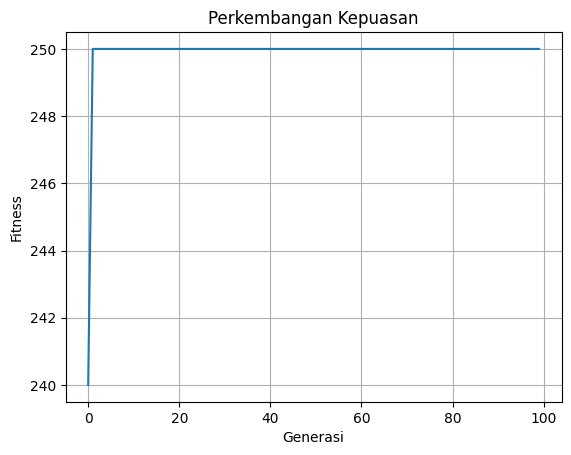

In [ ]:
import random
import matplotlib.pyplot as plt

# =========================================================
# DATA PENGELUARAN
# =========================================================
items = [
    ("Makan", 20000, 80),
    ("Kopi", 15000, 60),
    ("Jajan", 10000, 50),
    ("Transport", 10000, 70),
    ("Internet", 5000, 40),
]

BUDGET = 50000

POP_SIZE = 30
GENERATIONS = 100
MUTATION_RATE = 0.2

# =========================================================
# INIT
# =========================================================
def create_individual():
    return [random.randint(0,1) for _ in items]

def init_population():
    return [create_individual() for _ in range(POP_SIZE)]

# =========================================================
# FITNESS
# =========================================================
def fitness(ind):
    total_cost = 0
    total_value = 0

    for gene, (name, cost, value) in zip(ind, items):
        if gene == 1:
            total_cost += cost
            total_value += value

    if total_cost > BUDGET:
        return 0

    return total_value

# =========================================================
# SELECTION
# =========================================================
def selection(pop):
    return max(random.sample(pop, 3), key=fitness)

# =========================================================
# CROSSOVER
# =========================================================
def crossover(p1, p2):
    point = random.randint(1, len(p1)-1)
    return p1[:point] + p2[point:]

# =========================================================
# MUTATION
# =========================================================
def mutate(ind):
    for i in range(len(ind)):
        if random.random() < MUTATION_RATE:
            ind[i] = 1 - ind[i]
    return ind

# =========================================================
# DECODE
# =========================================================
def decode(ind):
    chosen = []
    total_cost = 0
    total_value = 0

    for gene, (name, cost, value) in zip(ind, items):
        if gene == 1:
            chosen.append(name)
            total_cost += cost
            total_value += value

    return chosen, total_cost, total_value

# =========================================================
# GA
# =========================================================
def GA():
    pop = init_population()
    best_hist = []

    print("\n===== OPTIMASI UANG JAJAN =====\n")

    for gen in range(GENERATIONS):

        pop = sorted(pop, key=fitness, reverse=True)

        best = pop[0]
        best_fit = fitness(best)

        best_hist.append(best_fit)

        if gen % 5 == 0:
            print(f"Gen {gen:3d} | Nilai kepuasan: {best_fit}")

        new_pop = pop[:2]

        while len(new_pop) < POP_SIZE:
            p1 = selection(pop)
            p2 = selection(pop)

            child = crossover(p1, p2)
            child = mutate(child)

            new_pop.append(child)

        pop = new_pop

    # =====================================================
    # HASIL
    # =====================================================
    best = sorted(pop, key=fitness, reverse=True)[0]
    chosen, cost, value = decode(best)

    print("\n===== HASIL AKHIR =====")
    print("Pilihan:", chosen)
    print("Total biaya:", cost)
    print("Total kepuasan:", value)

    if cost <= BUDGET:
        print("Penjelasan: Pengeluaran optimal sesuai budget.")
    else:
        print("Penjelasan: Melebihi budget (tidak valid).")

    # =====================================================
    # VISUAL
    # =====================================================
    plt.figure()
    plt.plot(best_hist)
    plt.title("Perkembangan Kepuasan")
    plt.xlabel("Generasi")
    plt.ylabel("Fitness")
    plt.grid()
    plt.show()

# RUN
GA()